# Multiple linear regressions

In [1]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

# 1 Dataset

In [2]:
x, y = make_regression(n_samples=100, n_features=2, noise = 10)


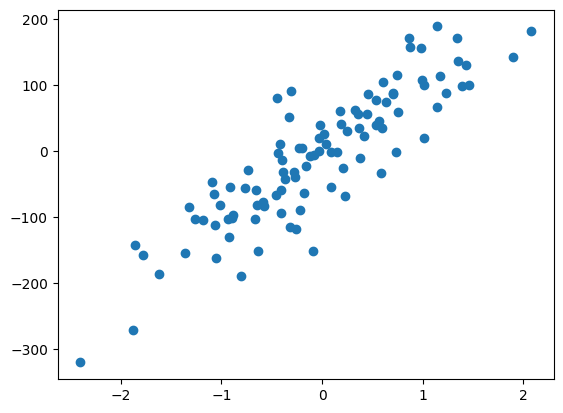

In [3]:
plt.scatter(x[:,0],y)

In [4]:
print(x.shape)
print(y.shape)

(100, 2)
(100,)


In [5]:
y = y.reshape(y.shape[0],1)
print(y.shape)

(100, 1)


In [6]:
# matrix X et biais
X = np.hstack((x, np.ones((x.shape[0],1))))
X.shape

(100, 3)

In [7]:
X[:10]

array([[-0.4456831 ,  2.30191355,  1.        ],
       [-0.03114904,  0.0356204 ,  1.        ],
       [-0.02674866,  0.09956468,  1.        ],
       [ 0.74991412, -0.19862389,  1.        ],
       [ 0.33054365,  0.74551469,  1.        ],
       [-0.89128945, -0.44201477,  1.        ],
       [ 0.63435275,  0.57717278,  1.        ],
       [-0.45975953, -0.7041951 ,  1.        ],
       [ 0.60319758,  1.23570081,  1.        ],
       [-0.76342597,  0.33948094,  1.        ]])

In [8]:
theta = np.random.randn(3,1)
theta

array([[-1.92001032],
       [ 0.26066811],
       [-0.80500264]])

# 2 Modèle

In [9]:
def model(X, theta):
    return X.dot(theta)

In [10]:
model(X, theta)

array([[ 0.65074898],
       [-0.73591106],
       [-0.7276916 ],
       [-2.29662039],
       [-1.24531794],
       [ 0.79106315],
       [-1.87251593],
       [-0.1058208 ],
       [-1.64104041],
       [ 0.74927495],
       [-0.94920285],
       [-0.69497161],
       [-3.12371606],
       [-1.43692542],
       [ 0.34087205],
       [-0.31779404],
       [-1.18509177],
       [ 0.06940877],
       [-1.22873744],
       [ 1.19459042],
       [-2.44254201],
       [ 0.37609289],
       [ 2.68148372],
       [ 0.87983199],
       [-0.90606529],
       [-0.65799747],
       [-0.72705249],
       [-1.19189949],
       [-1.78964584],
       [ 0.08020658],
       [-0.36875735],
       [ 0.830428  ],
       [-1.90784142],
       [-2.44606122],
       [ 0.67800551],
       [-3.31986424],
       [-1.53259583],
       [-1.63834948],
       [ 0.28017076],
       [ 2.9825744 ],
       [-3.91175274],
       [-4.66208949],
       [ 1.5475575 ],
       [-2.00979453],
       [-3.19061403],
       [-2

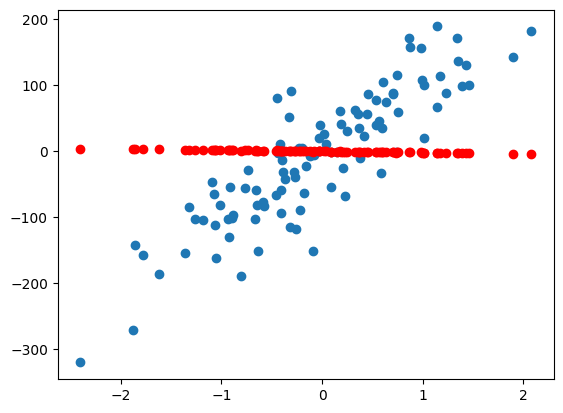

In [12]:
# plot pour la variable 1
plt.scatter(x[:,0], y)
plt.scatter(x[:,0], model(X, theta), color = "red")

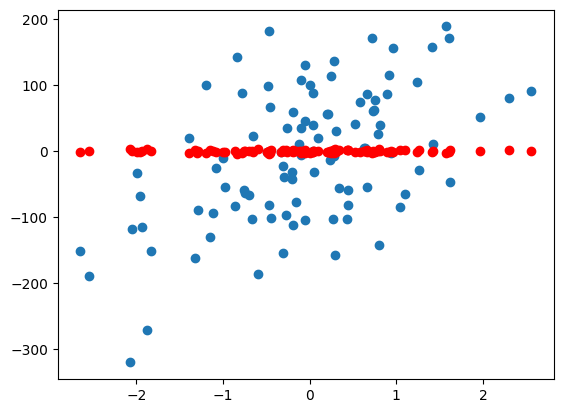

In [13]:
# plot pour la variable 2
plt.scatter(x[:,1], y)
plt.scatter(x[:,1], model(X, theta), color = "red")

# Cost Functions

In [14]:
def cost_function(X, y, theta):
    m = len(y)
    return 1/(2*m) * np.sum((model(X, theta) - y) ** 2)

In [15]:
cost_function(X, y, theta)

np.float64(5154.75456003206)

# Gradient & Gradient Descent

In [16]:
def grad(X, y, theta):
    m = len(y)
    return 1/m * X.T.dot(model(X, theta) - y)

In [17]:
def GradientDescent(X, y, theta, learning_rate, n_iteration):
    cost_history = np.zeros(n_iteration)
    for i in range(0, n_iteration):
        theta -= learning_rate * grad(X, y, theta)
        cost_history[i] = cost_function(X, y, theta)
    return theta, cost_history


# Machine Learning !!!

In [18]:
theta_final, cost_history = GradientDescent(X, y, theta, learning_rate=0.01, n_iteration=1000)

In [19]:
theta_final

array([[96.83781416],
       [45.79825594],
       [-0.85120464]])

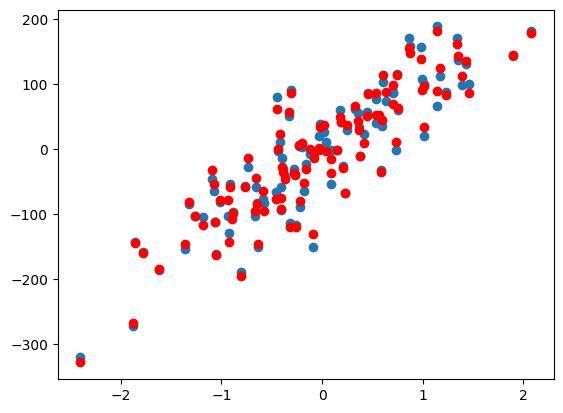

In [20]:
# Variable 1
predictions = model(X, theta_final)
plt.scatter(x[:,0],y)
plt.scatter(x[:,0], predictions, color = "red")

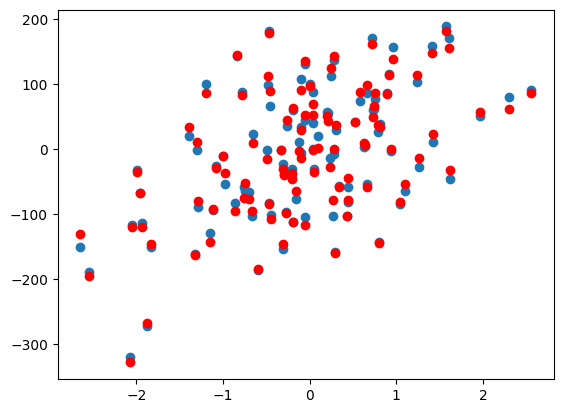

In [21]:
# Variable 1
predictions = model(X, theta_final)
plt.scatter(x[:,1],y)
plt.scatter(x[:,1], predictions, color = "red")

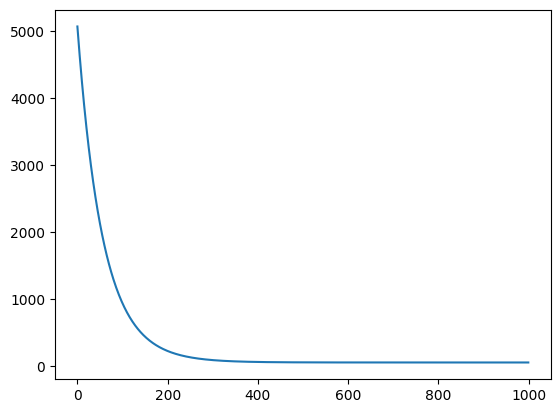

In [22]:
plt.plot(range(1000), cost_history)

# Coefficient de détermination R^2

In [23]:
def coef_determination(y, pred):
    u = ((y - pred) ** 2).sum()
    v = ((y - y.mean()) ** 2).sum()
    R_carre = 1 - ( u / v )
    return R_carre

In [24]:
coef_determination(y, predictions)

np.float64(0.9902102742051129)